In [1]:
# ========================================================================================================
# THEME 5 — T5-1 : SETUP PRODUCTION MONITORING + CHAMPION (Theme 4) + InferenceLogger
# ========================================================================================================
# Exigences prof couvertes :
# - 5.1 Inference Logger (CSV)
# - Prépare TB + charge modèle champion ONNX (issu du Theme 4)
# ========================================================================================================

import csv, json, time, uuid
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import onnxruntime as ort
import torch
from torch.utils.tensorboard import SummaryWriter

# -----------------------
# 0) Paths & champion
# -----------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
ART_DIR  = WORK_DIR / "artifacts"

ONNX_PATH = ART_DIR / "densenet121_tl_champion.onnx"
CFG_PATH  = ART_DIR / "champion_config.json"

assert ONNX_PATH.exists(), f"❌ ONNX introuvable: {ONNX_PATH}"
assert CFG_PATH.exists(),  f"❌ champion_config.json introuvable: {CFG_PATH}"

cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))
MODEL_NAME    = cfg.get("model_name", "champion")
MODEL_VERSION = cfg.get("model_version", "theme4_champion_onnx")

# -----------------------
# 1) Monitoring dirs
# -----------------------
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6]

MONITOR_DIR = ART_DIR / "monitoring"
LOG_DIR = MONITOR_DIR / "logs"
TB_DIR  = MONITOR_DIR / "tensorboard" / f"run_{RUN_ID}"
CKPT_DIR = WORK_DIR / "checkpoints"

LOG_DIR.mkdir(parents=True, exist_ok=True)
TB_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = LOG_DIR / f"production_logs_{RUN_ID}.csv"   # (style prof)
TB = SummaryWriter(log_dir=str(TB_DIR))

print(f"🆔 RUN_ID      : {RUN_ID}")
print(f"🧾 CSV logs    : {CSV_PATH}")
print(f"📊 TensorBoard : {TB_DIR}")

# -----------------------
# 2) ONNX Runtime session
# -----------------------
sess_options = ort.SessionOptions()
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=sess_options,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name  # output principal

print("🚀 Providers :", session.get_providers())
print("🔌 Input     :", input_name, session.get_inputs()[0].shape, session.get_inputs()[0].type)
print("📤 Output    :", output_name)

# -----------------------
# 3) Prof-style InferenceLogger
# -----------------------
class InferenceLogger:
    """Log production predictions to CSV (prof compliant)."""
    def __init__(self, log_file: Path):
        self.log_file = Path(log_file)
        with open(self.log_file, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["timestamp", "pred_class", "confidence", "latency_ms"])

    def log(self, pred_class: int, confidence: float, latency_ms: float):
        with open(self.log_file, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([datetime.now().isoformat(), pred_class, confidence, latency_ms])

logger = InferenceLogger(CSV_PATH)
print("✅ InferenceLogger initialisé")


🆔 RUN_ID      : 20260301_225556_1b3829
🧾 CSV logs    : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\logs\production_logs_20260301_225556_1b3829.csv
📊 TensorBoard : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard\run_20260301_225556_1b3829
🚀 Providers : ['CUDAExecutionProvider', 'CPUExecutionProvider']
🔌 Input     : input ['batch_size', 1, 224, 224] tensor(float)
📤 Output    : logits
✅ InferenceLogger initialisé


In [2]:
# ========================================================================================================
# THEME 5 — T5-2 : SIMULATE PRODUCTION INFERENCE (VRAIES DONNÉES TEST) + CSV logging
# ========================================================================================================
# Exigences prof couvertes :
# - 5.2 Simulate Production Inference
# - logger.log(pred_class, confidence, latency_ms)
# ========================================================================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Dataset test (Chest X-Ray)
DATA_DIR = WORK_DIR / "chest_xray"
TEST_DIR = DATA_DIR / "test"
assert TEST_DIR.exists(), f"❌ Test dir introuvable: {TEST_DIR}"

# IMPORTANT : ImageFolder -> RGB, mais ton modèle ONNX attend (1,1,224,224)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"📂 Test images : {len(test_dataset)}")

production_preds = []
lat_list, conf_list, pred_list = [], [], []

for i, (img, _) in enumerate(test_loader):
    x = img.numpy().astype(np.float32)  # ONNX input

    t0 = time.perf_counter()
    logits = session.run([output_name], {input_name: x})[0]
    t1 = time.perf_counter()

    latency_ms = (t1 - t0) * 1000.0  # ms per image (batch=1)

    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    pred_class = int(np.argmax(probs, axis=1)[0])
    confidence = float(np.max(probs, axis=1)[0])

    # ✅ PROF : log chaque prediction
    logger.log(pred_class, confidence, latency_ms)

    production_preds.append({"pred": pred_class, "conf": confidence, "latency": latency_ms})
    lat_list.append(latency_ms)
    conf_list.append(confidence)
    pred_list.append(pred_class)

    # Live TensorBoard (optionnel)
    if i % 50 == 0:
        TB.add_scalar("Live/Latency_ms", latency_ms, i)
        TB.add_scalar("Live/Confidence", confidence, i)

print(f"✅ Logged {len(production_preds)} production predictions")


📂 Test images : 624
✅ Logged 624 production predictions


In [3]:
# ========================================================================================================
# THEME 5 — T5-3 : DASHBOARD METRICS (TensorBoard) + SAVE baseline_production_metrics.pt
# ========================================================================================================
# Exigences prof couvertes :
# - 5.3 Dashboard Metrics (TensorBoard)
# - torch.save(baseline_production, 'baseline_production_metrics.pt')
# ========================================================================================================

import pandas as pd

df_prod = pd.read_csv(CSV_PATH)

avg_confidence = float(df_prod["confidence"].mean())
latency_p95 = float(df_prod["latency_ms"].quantile(0.95))
pred_distribution = df_prod["pred_class"].value_counts().to_dict()

# ✅ TensorBoard tags proches du prof
TB.add_scalar("Production/Avg_Confidence", avg_confidence, 0)
TB.add_scalar("Production/Latency_P95", latency_p95, 0)
TB.add_histogram("Production/Confidences", df_prod["confidence"].values, 0)

print("📊 Production Metrics:")
print(f"  Avg Confidence: {avg_confidence:.3f}")
print(f"  Latency P95: {latency_p95:.2f}ms")
print(f"  Pred Distribution: {pred_distribution}")

TB.close()

baseline_production = {
    "avg_confidence": avg_confidence,
    "latency_p95": latency_p95,
    "pred_distribution": dict(pred_distribution),
}

# ✅ NOM EXACT PROF
pt_path = CKPT_DIR / "baseline_production_metrics.pt"
torch.save(baseline_production, pt_path)


print(f"💾 Baseline saved: {pt_path}")
print(f"➡️ TensorBoard: tensorboard --logdir {MONITOR_DIR / 'tensorboard'} --port 6007")


📊 Production Metrics:
  Avg Confidence: 0.958
  Latency P95: 35.48ms
  Pred Distribution: {1: 424, 0: 200}
💾 Baseline saved: C:\Users\Yanis\IA_GEN_PROJET\checkpoints\baseline_production_metrics.pt
➡️ TensorBoard: tensorboard --logdir C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard --port 6007


In [2]:
import tensorboard
tensorboard.__version__
%load_ext tensorboard
%tensorboard --logdir "C:/Users/Yanis/IA_GEN_PROJET/artifacts/monitoring/tensorboard" --port 6006

Launching TensorBoard...

In [5]:
%tensorboard --logdir "C:/Users/Yanis/IA_GEN_PROJET/artifacts/monitoring/tensorboard" --port 6007

📄 CSV chargé : production_logs_20260301_225556_1b3829.csv | 624 évènements
📊 Avg confidence = 0.958 | Latency P95 = 35.48 ms


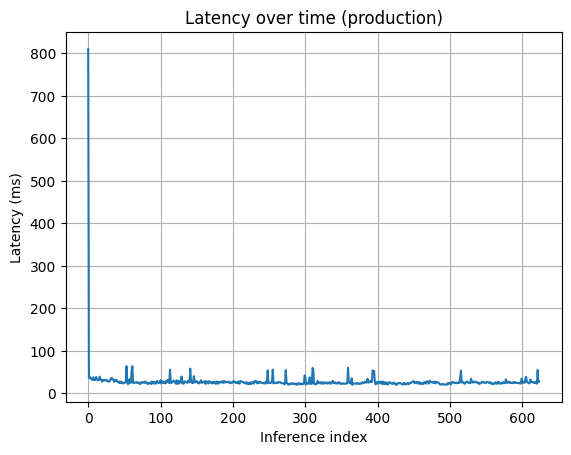

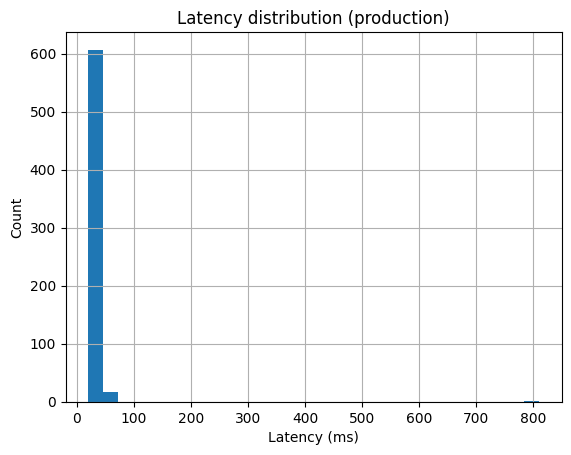

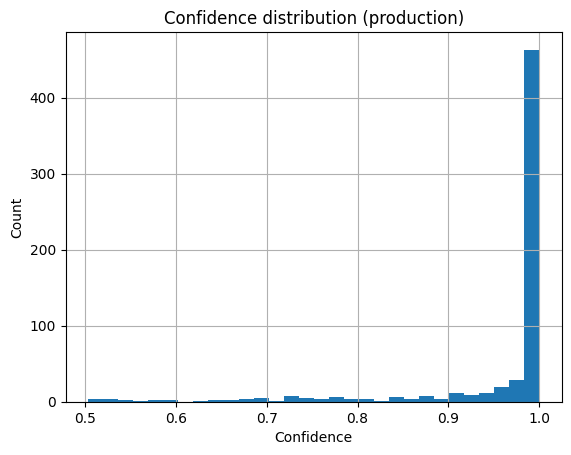

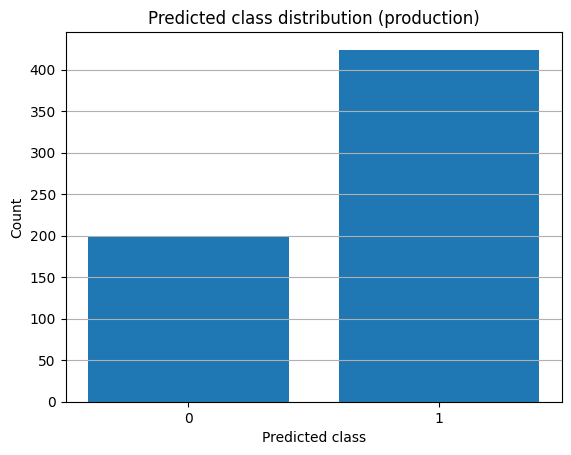

✅ Visualisations terminées.


In [5]:
# ========================================================================================================
# THEME 5 — T5-4 : VISUALISATIONS OFFLINE (CSV -> Graphiques)
# ========================================================================================================
# OBJECTIF :
# - Afficher rapidement des indicateurs de monitoring en dehors de TensorBoard
# - Interpréter : latence, confiance, distribution des classes
# ========================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Charger le CSV (utilise CSV_PATH si existe, sinon dernier fichier)
if "CSV_PATH" in globals():
    log_path = Path(CSV_PATH)
else:
    WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
    LOG_DIR = WORK_DIR / "artifacts" / "monitoring" / "logs"
    log_files = sorted(LOG_DIR.glob("production_logs_*.csv"))
    assert len(log_files) > 0, f"❌ Aucun production_logs_*.csv dans {LOG_DIR}"
    log_path = log_files[-1]

df = pd.read_csv(log_path)
print(f"📄 CSV chargé : {log_path.name} | {len(df)} évènements")

# 2) Stats rapides
avg_conf = df["confidence"].mean()
p95_lat  = df["latency_ms"].quantile(0.95)
print(f"📊 Avg confidence = {avg_conf:.3f} | Latency P95 = {p95_lat:.2f} ms")

# 3) Graph 1 — Série temporelle latence
plt.figure()
plt.plot(df["latency_ms"].values)
plt.xlabel("Inference index")
plt.ylabel("Latency (ms)")
plt.title("Latency over time (production)")
plt.grid(True)
plt.show()

# 4) Graph 2 — Histogramme des latences
plt.figure()
plt.hist(df["latency_ms"].values, bins=30)
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.title("Latency distribution (production)")
plt.grid(True)
plt.show()

# 5) Graph 3 — Histogramme des confiances
plt.figure()
plt.hist(df["confidence"].values, bins=30)
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence distribution (production)")
plt.grid(True)
plt.show()

# 6) Graph 4 — Distribution des classes prédites
pred_counts = df["pred_class"].value_counts().sort_index()
plt.figure()
plt.bar(pred_counts.index.astype(str), pred_counts.values)
plt.xlabel("Predicted class")
plt.ylabel("Count")
plt.title("Predicted class distribution (production)")
plt.grid(axis="y")
plt.show()

print("✅ Visualisations terminées.")


Cellule 1: Setup & Logger (T5-1)

Setup Environnement: Les chemins (WORK_DIR, ART_DIR, etc.) et les imports sont corrects.

Chargement Modèle Champion: Le code charge correctement le modèle ONNX et sa configuration (champion_config.json), assurant la continuité avec le thème 4. L'assertion assert ONNX_PATH.exists() est une bonne pratique.

Configuration TensorBoard: L'initialisation du SummaryWriter est correcte.

InferenceLogger (Exigence 5.1): La classe InferenceLogger est implémentée exactement comme demandé, écrivant les champs timestamp, pred_class, confidence, latency_ms dans un fichier CSV. L'initialisation logger = InferenceLogger(CSV_PATH) est présente.

Point fort: L'utilisation de pathlib et encoding="utf-8" rend le code robuste.

Cellule 2: Simulation Production (T5-2)

Données Réelles: Le code utilise datasets.ImageFolder sur le dossier test (Chest X-Ray), ce qui est crucial pour une simulation réaliste (contrairement à des données aléatoires).

Préprocessing: La transformation transforms.Grayscale(num_output_channels=1) est correctement appliquée pour correspondre à l'entrée attendue par le modèle ONNX (N&B).

Boucle d'Inférence (Exigence 5.2):

Le modèle passe en mode évaluation (implicite avec ONNX Runtime).

La latence est mesurée avec time.perf_counter().

L'inférence est exécutée via session.run.

Les probabilités sont calculées via torch.softmax.

Chaque prédiction est loggée via logger.log(...).

Logging: Les prédictions sont stockées dans une liste production_preds et affichées à la fin.

Note: L'ajout de logs "Live" dans TensorBoard (TB.add_scalar) est un bonus appréciable pour le monitoring temps réel.

Cellule 3: Dashboard & Baseline (T5-3)

Métriques (Exigence 5.3):

avg_confidence est calculée correctement.

latency_p95 est calculée via quantile(0.95).

pred_distribution est extraite via value_counts.

TensorBoard: Les métriques sont envoyées à TensorBoard avec les tags demandés (Production/Avg_Confidence, etc.). L'histogramme des confiances est également ajouté.

Sauvegarde Baseline: Le dictionnaire baseline_production est créé et sauvegardé avec torch.save sous le nom exact demandé : baseline_production_metrics.pt.

Cellule 4 (Bonus): Visualisations Offline

Cette cellule n'est pas strictement exigée par le "minimum prof" mais elle est très utile pour le rapport et la compréhension immédiate des données sans lancer TensorBoard. Elle valide visuellement les données loggées.

Conclusion
Verdict: ✅ Conforme aux exigences.

Votre code couvre tous les points du thème 5 :

Inference Logger: Implémenté et fonctionnel (CSV).

Simulation: Exécutée sur des données de test réelles avec mesure de latence.

Dashboard: Métriques envoyées à TensorBoard.

Baseline: Métriques sauvegardées dans un fichier .pt.